# 09 — Prepare Descriptors for Complex Phase Prediction

Prepares BOP, ACE, and SOAP descriptors for all configurations of the complex TCP phases (R, M, P, δ) to be used in the prediction notebooks.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/{R,M,P,delta}_structures.pkl` — structure objects (available on Zenodo)
- `Fe-Mo/Descriptors/PREDICTION_Fe-Mo_{R,M,P,delta}_0.7dprojections_0.5os_table_WUBIND_16.pkl` — pre-computed BOP descriptors (available on Zenodo)

## Outputs
- `Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_*.pkl` — coordination-averaged prediction descriptors

## Notes
> Pre-computed BOP descriptors for the complex phases are provided in the Zenodo archive. Download them before running this notebook.

> ACE and SOAP descriptors for complex phases can be recomputed if `python-ace` and DScribe are available.



# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
try:
    from dependencies.bopdftprojections.bopdftprojections.projections import Projections
    _has_bopdftprojection = True
except (ModuleNotFoundError, ImportError):
    _has_bopdftprojection = False
from Tools import PlottingTools as plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
import logging
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
MAG = 0
if MAG == 0:
    target_case = 'EF_nmhcp'
elif MAG == 1:
    target_case = 'EF_fmbcc'

descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = logging.getLogger()
logging.basicConfig( format='%(message)s',level=logging.INFO,)


In [3]:
import shutil

# Enable LaTeX text rendering only if a TeX Live toolchain is available.
required_tex_bins = ("latex", "dvipng", "kpsewhich")
has_texlive = all(shutil.which(cmd) is not None for cmd in required_tex_bins)

plt.rc("text", usetex=has_texlive)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)

if not has_texlive:
    print(
        "TeX Live not fully available (missing one of: latex, dvipng, kpsewhich). "
        "Using matplotlib internal text rendering."
    )

In [4]:
import logging

In [5]:
from mendeleev import element
from ase import Atoms

In [6]:
import Tools.PredictionTools.MakeAtomsOjects as MAO

In [7]:
DS = Dataset(dataset=dataset, target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]
TRAIN_RBS = BS.query('Phase == "R"')

In [8]:
BS.filter(regex = "EF")

,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.374554,0.363607,0.351444
...,...,...,...
Fe_pv30.sigma.FM,0.075258,0.075258,0.075258
Fe_pv6.C15.FM,0.144169,0.144169,0.144169
Mo_sv8.A15.NM,0.095306,0.095306,0.095306
Mo_sv6.C15.NM,0.367463,0.367463,0.367463


In [9]:
target_case

'EF_nmhcp'

In [10]:
DS.StructureNames[DS.StructureNames == 'M']

Series([], Name: Phase, dtype: object)

In [11]:
train_features = DS.Features

In [12]:
train_features['atomic']['Structure'].max()

10

In [13]:
train_features['atomic']['Structure'].min()

0

In [14]:
pd.concat([ DS.StructureNames, train_features['atomic']['Structure']], axis =1 ).reset_index(drop=True).drop_duplicates().sort_values('Structure')

,Phase,Structure
162,A15,0
6,C14,1
161,C15,2
0,C36,3
1,R,4
11,chi,6
2,mu,9
3,sigma,10


Text(0, 0.5, '$\\Delta E_F$ (meV/at)')

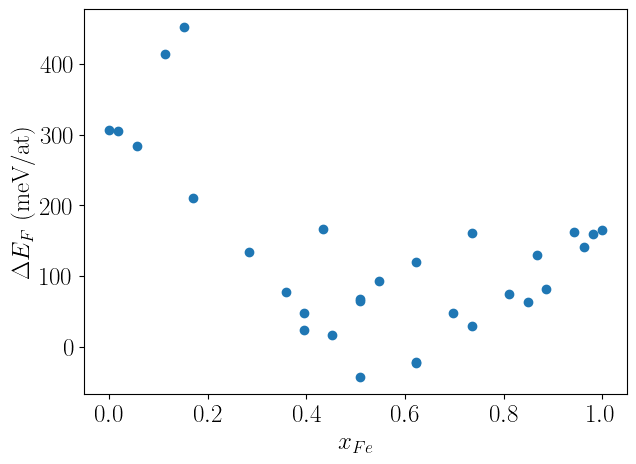

In [15]:
fig, axes = plt.subplots()
axes.scatter(TRAIN_RBS['Fe_pv'], TRAIN_RBS['EF_nmhcp']*1000)
axes.set_xlabel('$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_F$ (meV/at)')

In [16]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [17]:
LearningAtomsObjects = pd.read_json('Fe-Mo/Atomsobjects/Fe-Mo-POSCAR.initial-rescaled-AtomsObjects.json').query('index.str.contains("R-.*NM$")')
LearningAtomsObjects['atoms'] = LearningAtomsObjects['atoms'].map(Atoms.fromdict)

In [18]:
AtomsObjects = {'R' :
#                        {'permutations': LearningAtomsObjects.index.str.split('\.').map(lambda s: s[1]),
#                         'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}
                    {'permutations': permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}, 
#                    'R_old':
#                    {'permutations': old_permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset, 'Atomsobjects/R_structures_old.pkl')},
                    'P' : 
                    {'permutations': permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
#                    'P_old' : 
#                    {'permutations': old_permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
                    'delta': 
                    {'permutations': permutate('delta', 2, 14), 'atoms_objects_file' : os.path.join(dataset,'Atomsobjects/delta_structures.pkl') },
                    'M':
                    {'permutations': permutate('M', 2, 11 ), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects', 'M_structures.pkl' )}
                   }

In [19]:
AtomsObjects['R']['permutations'][0], AtomsObjects['R']['permutations'][-1], 

('R-AAAAAAAAAAA', 'R-BBBBBBBBBBB')

In [20]:
atom_volumes = {'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [21]:
#atom_volumes = MAO.get_atom_volume_from_mp({'Fe' : 'mp-13', 'Mo' : 'mp-129'})
# was taking volumes from MP , but MPRester is not working due to incompatibilities

In [22]:
atom_volumes

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [23]:
for name, phase_atoms in AtomsObjects.items():
    print(name)
    if os.path.exists(phase_atoms['atoms_objects_file']):
        phase_atoms['Atoms'] = pd.read_pickle(phase_atoms['atoms_objects_file'])
    else:
        phase_atoms['Atoms'] = make_all_atoms_objects(phase_atoms['permutations'], atom_volumes_def=atom_volumes)
        phase_atoms['Atoms'] = phase_atoms['Atoms'].to_frame()
        phase_atoms['Atoms'].index = phase_atoms['Atoms'].index +'.NM'
        phase_atoms['Atoms'].columns = ['atoms']
        phase_atoms['Atoms'].to_pickle(phase_atoms['atoms_objects_file'])
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-AAAAAAAAAAA", '')
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-BBBBBBBBBBB", '')

R
P
delta
M


In [24]:
AtomsObjects['R']['Atoms']

,atoms
Fe_pv53.R.NM,"(Atom('Fe', [5.614366370550564, 5.130930694031..."
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.63927762944244, 5.1536969216767..."
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.712721111029581, 5.220816412832..."
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [6.12878666841063, 5.6010558553976..."
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [6.191143463482836, 5.658043300231..."
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."


In [25]:
len(AtomsObjects['R']['Atoms'].iloc[0].values[0])

53

In [26]:
len(AtomsObjects['M']['Atoms'].iloc[0].values[0])

52

In [27]:
len(AtomsObjects['P']['Atoms'].iloc[0].values[0])

56

In [28]:
len(AtomsObjects['delta']['Atoms'].iloc[0].values[0])

56

## compare atoms objects to the ones used for learning

Text(0.5, 0, 'volume of unit cell in training set')

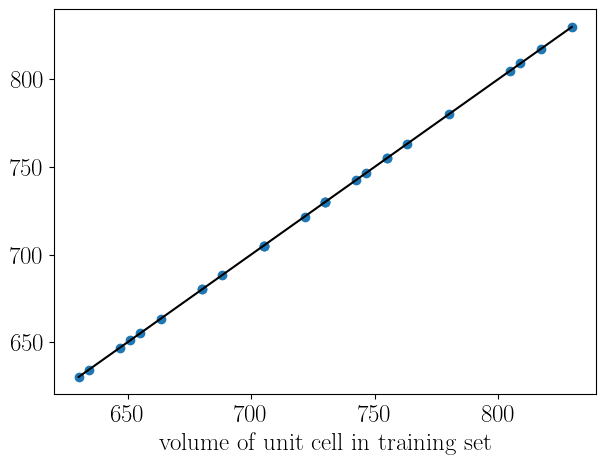

In [29]:
not_created = AtomsObjects['R']['Atoms'].index.difference(LearningAtomsObjects.index)

intersection = LearningAtomsObjects.index.intersection(AtomsObjects['R']['Atoms'].index)

created_intersection_volumes = AtomsObjects['R']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())

#alt_created_intersection_volumes = binaries_predict['R_old']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())


intersection_volumes = LearningAtomsObjects.atoms[intersection].map(lambda a: a.get_volume())

fig, axes = plt.subplots()
axes.scatter(intersection_volumes, created_intersection_volumes)
#axes.scatter(intersection_volumes, alt_created_intersection_volumes)
axes.plot([ created_intersection_volumes.min(), created_intersection_volumes.max() ], [ created_intersection_volumes.min(), created_intersection_volumes.max() ], '-k')
axes.set_xlabel('volume of created unit cell')
axes.set_xlabel('volume of unit cell in training set')

In [30]:
theatoms=AtomsObjects['P']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [31]:
theatoms=AtomsObjects['R']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [32]:
theatoms=AtomsObjects['delta']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [33]:
theatoms=AtomsObjects['M']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

# Make BS 

In [34]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [35]:
BS_predict = {}
for name, phaseAtoms in AtomsObjects.items():
    BS_predict[name] = phaseAtoms['Atoms'].atoms.map(len)
    BS_predict[name].name = 'num_atoms'
    compo = pd.DataFrame.from_dict(
        phaseAtoms['Atoms'].atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
        orient = 'index'
    ).fillna(0)
    compo['Fe_pv'] = compo['Fe'] / BS_predict[name]
    compo['Mo_sv'] = 1 - compo['Fe_pv']
    compo['Mag'] = MAG #FM
    compo['nelem'] = phaseAtoms['Atoms'].atoms.map(get_nelem)
    BS_predict[name] = pd.concat([BS_predict[name], compo], axis = 1)

In [36]:
BS_predict['R']['Structure'] = 4
#BS_predict['R_old']['Structure'] = 4

In [37]:
BS_predict['P']['Structure'] = 11

In [38]:
BS_predict['delta']['Structure'] = 11

In [39]:
BS_predict['M']['Structure'] = 11

In [40]:
BS.query('Phase == "R"').columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc'],
      dtype='object')

# CALCULATE FEATURES 

In [41]:
import shutil

In [42]:
features = {}

In [43]:
elements = dataset.split('-')

## BOP Features 

In [44]:
from BopFoxFeaturizer.Featurizer import BopfoxFeatures
print("bopfoxfeaturizer import OK")
from Tools.DatasetTools.Commoms import *
os.environ['PATH']+=':'+os.path.join(os.getcwd(),'dependencies/bopfox/src/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

bopfoxfeaturizer import OK


### Define parameters for BOP

In [45]:
DS.Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'NOZERO-ACE', 'NOZERO_NOONE-ACE', 'NOZERO_NOONE_NOTWO-ACE', 'NOTHREE-ACE', 'NOTHREE-NOTWO-ACE', 'NOTHREE-NOTWO_NOONE-ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'NOZERO-ACE no CNAV', 'NOZERO_NOONE-ACE no CNAV', 'NOZERO_NOONE_NOTWO-ACE no CNAV', 'NOTHREE-ACE no CNAV', 'NOTHREE-NOTWO-ACE no CNAV', 'NOTHREE-NOTWO_NOONE-ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [46]:
globalmoments = 16
model_definitions = {
    '0.7dprojections_0.5os': {'model_maker_options' : {
        'element_pairs_kwargs' : {
            'bond_integral_scale': 0.7,
        },
        'atom_blocks_kwargs': {
            'onsite_levels_scale' : 0.5,
            'select_orbitals' : {'Fe': 'd', 'Mo' : 'd'}
        },
    },
    'moments' : globalmoments
    },
}
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [47]:
if _has_bopdftprojection:
    P = Projections()
    P.readbxmodels()
    P.get_bond_chunks()
    P.get_autobonds()
    P.get_all_onsite_levels()
    P.get_restructured_projections()
    def create_modelfile(acompound, target_model_filename, modelname='projections', element_pairs_kwargs={}, atom_blocks_kwargs={} ):
        print(acompound)
        if 'canonical' not in modelname :
            model_filename = P.save_abond_bx(acompound, return_filename=True,
                                            modelname=modelname, 
                                            element_pairs_kwargs=element_pairs_kwargs,
                                            atom_blocks_kwargs=atom_blocks_kwargs)
            print(model_filename)
        else:
            model_filename = C.base_canonical #f'models/W_canonical.bx'
        shutil.copy(model_filename, target_model_filename)
    def replace_symbols(theatoms, replacements=None):
        new_symbols = theatoms.get_chemical_symbols()
        if replacements is not None:
            for original, replacement in replacements.items():
                new_symbols = [s.replace(original, replacement) for s in new_symbols]
        new_atoms = theatoms.copy()
        new_atoms.set_chemical_symbols(new_symbols)
        return new_atoms


### Calculate or load precalculated BOP features

In [48]:
bop_features = {}
bop_features_files = {}

In [49]:
cwd = os.getcwd()
binary = os.path.join(cwd, 'dependencies', 'bopfox','src', 'bopfox')
if os.path.exists(binary):
    _has_bopfox = True

In [50]:
for (model, definition), (phase, atoms_df) in product(model_definitions.items(), AtomsObjects.items()):
    if _has_bopdftprojection:
        if 'moments' in definition.keys():
            thismoments = definition['moments']
        else:
            thismoments = 16
        if (model, thismoments, phase) in bop_features.keys():
            continue
        create_model_options = {}
        if 'model_maker_options' in definition.keys():
            create_model_options.update(definition['model_maker_options'])
    use_elements = copy.copy(elements)
    if _has_bopdftprojection:
        if 'replace atoms' in definition.keys():
            for realelement, targetelement in definition['replace atoms'].items():
                use_elements = set([s.replace(realelement, targetelement) for s in use_elements])
    components = ''.join(use_elements)
    if _has_bopdftprojection:
        modelsfile = os.path.join('models', f'{dataset}-{components}_{model}.bx')
        if not os.path.exists(os.path.dirname(modelsfile)):
            os.makedirs(os.path.dirname(modelsfile))
        create_modelfile(use_elements,modelsfile, modelname=model, **create_model_options,   )
        if 'replace atoms' in definition.keys():
            ApplyOnAtoms = atoms_df['atoms'].apply(replace_symbols, replacements = definition['replace atoms'])
        else:
            ApplyOnAtoms = atoms_df.atoms

    print('atoms: ', phase, 'model: ', model, '  cutoff: ', cutoff, ' moments:', globalmoments)
    bop_features_files[(model, globalmoments, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{cutoff}_WUBIND_{globalmoments}.pkl')
    if not os.path.exists(bop_features_files[(model, globalmoments, phase)]):
        if _has_bopfox:
            BOPC = BopfoxFeatures(
                ApplyOnAtoms,modelsfile, modelname=model,
                cutoffby=cutoff, 
                moments = thismoments,
                binary = binary,
                savelog=False
                )
            BOPC.featurize_dataframe(input_pickle=features, output_pickle=features, max_workers=12)
            bop_features[(model, thismoments, phase)] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) 
            bop_features[(model, thismoments, phase)].to_pickle(features[(model, thismoments, phase)])
        else: 
            raise Exception('bopfox not installed, install bopfox')
    else:
        bop_features[(model, globalmoments, phase)] = pd.read_pickle(bop_features_files[(model, globalmoments, phase)])

atoms:  R model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  P model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  delta model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  M model:  0.7dprojections_0.5os   cutoff:  table  moments: 16


In [51]:
for (model, thismoments, phase), feature in bop_features.items(): 
    if not feature.index.str.contains('NM$', regex=True).all():
        feature.index = feature.index+'.NM'
        bop_features[(model, globalmoments, phase)].to_pickle(features[(model, globalmoments, phase)])

In [52]:
cn_persite

{'A15': array([14, 14, 14, 14, 14, 14, 12, 12]),
 'C14': array([16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]),
 'C15': array([16, 16, 12, 12, 12, 12]),
 'C36': array([16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12]),
 'bcc': array([14]),
 'chi': array([16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]),
 'fcc': array([12]),
 'hcp': array([12, 12]),
 'mu': array([12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 14, 14]),
 'sigma': array([12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12,
        12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14]),
 'R': array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16,
        16, 16]),
 'delta': array([15, 15, 15, 15, 15, 15, 15, 15, 1

In [53]:
for name, struc in cn_persite.items():
    print(name, len(struc))

A15 8
C14 12
C15 6
C36 24
bcc 1
chi 29
fcc 1
hcp 2
mu 13
sigma 30
R 53
delta 56
P 56
M 52


In [54]:
for phase, list_of_atoms in AtomsObjects.items():
    print(phase, len(list_of_atoms))

R 3
P 3
delta 3
M 3


 ### CNav for bop

In [55]:
bop_cnav_file = {}

In [56]:
name

'M'

In [57]:
trainingname = {'0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP'}

bop_cnav = {}
for name, feature  in bop_features.items():
    specialcolumns =['U_bind','U_bond_atom', 'modelsfile']#, 'U_bond_atom_list'] 
    bop_cnav_file[name] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(bop_features_files[name]).replace('pkl', 'csv'))

    CNList = pd.Series([cn_persite[name[-1]]]*len(feature), index=feature.index)

    if os.path.exists(bop_cnav_file[name]):
        bop_cnav[name] = pd.read_csv(bop_cnav_file[name], index_col=0).astype(float)  # for some reason some values are objects
    else:
        columnstoexpand = feature.columns.drop([column for column in specialcolumns if column in feature.columns])
        df = gf.array_expansions(feature.dropna(), columnstoexpand)
        ThisCoordination = CNList[feature.index]
        print(name)
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        bop_cnav[name] = pd.concat(
            [
                BS_predict[name[-1]][['Mag', 'Structure']].loc[df.index], 
                feature[specialcolumns[:-1]].loc[df.index],
                df, shape_factors
            ],
                axis=1)
        bop_cnav[name].to_csv(bop_cnav_file)
    intersection = DS.Features[trainingname[name[0]]].columns.intersection(bop_cnav[name].columns)
    bop_cnav[name] = bop_cnav[name][intersection]

## ACE features

In [58]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [59]:
AceConfig = copy.copy(default_options_dict)

In [60]:
AceConfig['elements'] = dataset.split('-')

In [61]:
ace_features = {}
ace_features_files = {}

In [62]:
model = 'ACE'
description = 'lmax=321'

ACEer = MyPyACECalculator(components=components, multispace_basis_config=AceConfig)
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    print('atoms: ', phase, 'model: ', 'ACE')
    ace_features_files[(model, description, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{description}.pkl')
    print('atoms: ', phase, 'model: ', 'ACE', ace_features_files[(model, description, phase)])
    if not os.path.exists(ace_features_files[(model, description, phase)]):
        cwd = os.getcwd()
        ace_features[(model, description, phase)] = acer.featurize_series(atoms_df.atoms)
        ace_features[(model, description, phase)].name = 'ace_projections'
        ace_features[(model, description, phase)] = ace_features[(model, description, phase)].to_frame()
        ace_features[(model, description, phase)].to_pickle(features[(model, description, phase)])
    else:
        ace_features[(model, description, phase)] = pd.read_pickle(ace_features_files[(model, description, phase)])
        if isinstance(ace_features[(model, description, phase)], pd.core.series.Series):
            ace_features[(model, description, phase)] = ace_features[(model, description, phase)].to_frame()
            ace_features[(model, description, phase)].columns = ['ace_projections']

atoms:  R model:  ACE
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_ACE_lmax=321.pkl
atoms:  P model:  ACE
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_ACE_lmax=321.pkl
atoms:  delta model:  ACE
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_ACE_lmax=321.pkl
atoms:  M model:  ACE
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_ACE_lmax=321.pkl


In [63]:
ace_cnav = {}
ace_cnav_files = {}
trainingname.update({'ACE': 'ACE'})

In [64]:
for (model, descriptor, phase), phase_ace_features in ace_features.items():
#    if 'ACE' not in model:
#        continue
    key = (model, descriptor, phase)
    print(model, descriptor, phase)
    ace_cnav_files[key] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(ace_features_files[key]))
    columnstoexpand = phase_ace_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_ace_features), index=phase_ace_features.index)
    if os.path.exists(ace_cnav_files[key]):
        print(phase, 'read ace features from ', ace_cnav_files[key])
        ace_cnav[key] = pd.read_csv(ace_cnav_files[key], index_col = 0)
    else:
        print(phase,  'calculate cnav ace features  ')
        expanded_ace = gf.array_expansions(phase_ace_features, ['ace_projections'])
        ace_cnav[key] = gf.featurize_dataframe(expanded_ace, CNList)
        ace_cnav[key].to_csv(ace_cnav_files[key])

    intersection = DS.Features[trainingname[key[0]]].columns.intersection(ace_cnav[key].columns)
    ace_cnav[key] = ace_cnav[key][intersection]

ACE lmax=321 R
R read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_R_ACE_lmax=321.pkl
ACE lmax=321 P
P read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_P_ACE_lmax=321.pkl
ACE lmax=321 delta
delta read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_delta_ACE_lmax=321.pkl
ACE lmax=321 M
M read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_M_ACE_lmax=321.pkl


## load SOAP

In [65]:
soapcases = ['specific']

In [66]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [67]:
#SOAPFEATURES = {}
#EXPANDED_SOAP = {}
#AVE_SOAP = {}
#variances = {}
#SEL_SOAP = {}
#FINAL_SOAP = {}
soap_features = {}
soap_features_files={}

In [68]:
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
)
model = 'SOAP'
param_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
description = 'specific_small'
trainingname.update({(model, description): 'SOAP_specific_small'})

species = [element(s).atomic_number for s in dataset.split('-')]

In [69]:


for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    print('atoms: ', phase, 'model: ', model)
    soap_features_files[(model, description, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{description}.pkl')
    print('atoms: ', phase, 'model: ', 'ACE', soap_features_files[(model, description, phase)])
    if  not os.path.exists(soap_features_files[(model, description, phase)]):
        cwd = os.getcwd()
        SOAPER = SOAP(species=species, **soap_params)
        soap_features[(model, description, phase)] = ApplyOnAtoms.atoms.map(SOAPER.create)
        soap_features[(model, description, phase)].name = model
        soap_features[(model, description, phase)] = soap_features[(model, description, phase)].to_frame()
        soap_features[(model, description, phase)].to_pickle(soap_features_files[(model, description, phase)])
    else:
        soap_features[(model, description, phase)] = pd.read_pickle(soap_features_files[(model, description, phase)])
        if isinstance(soap_features[(model, description, phase)], pd.core.series.Series):
            soap_features[(model, description, phase)] = soap_features[(model, description, phase)].to_frame()
            soap_features[(model, description, phase)].columns = [f'{model}_{description}']

atoms:  R model:  SOAP
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_SOAP_specific_small.pkl
atoms:  P model:  SOAP
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_SOAP_specific_small.pkl
atoms:  delta model:  SOAP
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_SOAP_specific_small.pkl
atoms:  M model:  SOAP
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_SOAP_specific_small.pkl


In [70]:
soap_cnav = {}
soap_cnav_files = {}
trainingname.update({'SOAP': 'SOAP_specific_small'})

In [71]:
for (model, descriptor, phase), phase_soap_features in soap_features.items():
#    if 'soap' not in model:
#        continue
    key = (model, descriptor, phase)
    print(model, descriptor, phase)
    soap_cnav_files[key] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(soap_features_files[key]))
    columnstoexpand = phase_soap_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_soap_features), index=phase_soap_features.index)
    if os.path.exists(soap_cnav_files[key]):
        print(phase, 'read soap features from ', soap_cnav_files[key])
        soap_cnav[key] = pd.read_csv(soap_cnav_files[key], index_col = 0)
    else:
        print(phase,  'calculate cnav soap features  ')
        expanded_soap = gf.array_expansions(phase_soap_features, [model])
        soap_cnav[key] = gf.featurize_dataframe(expanded_soap, CNList)
        soap_cnav[key].to_csv(soap_cnav_files[key])
    intersection = DS.Features[trainingname[key[0]]].columns.intersection(soap_cnav[key].columns)
    soap_cnav[key] = soap_cnav[key][intersection]

SOAP specific_small R
R read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_R_SOAP_specific_small.pkl
SOAP specific_small P
P read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_P_SOAP_specific_small.pkl
SOAP specific_small delta
delta read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_delta_SOAP_specific_small.pkl
SOAP specific_small M
M read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_M_SOAP_specific_small.pkl


In [72]:
soap_cnav[key]

,SOAP_0_0,SOAP_0_CN12,SOAP_0_CN13,SOAP_0_CN14,SOAP_0_CN15,SOAP_0_CN16,SOAP_1_0,SOAP_1_CN12,SOAP_1_CN13,SOAP_1_CN14,...,SOAP_256_0,SOAP_261_0,SOAP_262_0,SOAP_262_CN14,SOAP_263_0,SOAP_263_CN14,SOAP_267_0,SOAP_268_0,SOAP_268_CN14,SOAP_269_0
Fe_pv52.M-AAAAAAAAAAA.NM,0.019788,1.056420e-02,0.0,3.060644e-03,3.077741e-03,3.085144e-03,0.000230,2.795656e-04,0.0,7.917069e-06,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM,0.018235,1.056022e-02,0.0,3.057411e-03,3.075944e-03,1.541311e-03,0.000278,2.934316e-04,0.0,1.585964e-05,...,0.000019,-0.000003,0.000005,7.514872e-07,-0.000007,-1.111957e-06,0.000010,-0.000008,-1.356609e-06,0.000012
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM,0.018241,1.055697e-02,0.0,3.061842e-03,3.080179e-03,1.541814e-03,0.000268,3.006150e-04,0.0,7.462504e-06,...,0.000012,-0.000003,0.000004,3.929398e-07,-0.000006,-6.413201e-07,0.000010,-0.000008,-8.515937e-07,0.000012
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM,0.016685,1.054989e-02,0.0,3.057565e-03,3.077704e-03,3.257728e-07,0.000317,3.193487e-04,0.0,1.710361e-05,...,0.000027,-0.000005,0.000008,1.056580e-06,-0.000011,-1.597889e-06,0.000018,-0.000014,-1.987250e-06,0.000021
Fe_pv48Mo_sv4.M-AAAAAAAABAA.NM,0.018242,1.056691e-02,0.0,3.053871e-03,1.538062e-03,3.083351e-03,0.000265,2.817532e-04,0.0,2.198906e-05,...,0.000019,-0.000003,0.000005,9.958299e-07,-0.000007,-1.312208e-06,0.000010,-0.000008,-1.410464e-06,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv4Mo_sv48.M-BBBBBBBBABB.NM,0.001508,1.336945e-08,0.0,4.447231e-09,1.508312e-03,3.695406e-09,0.000052,-5.101314e-08,0.0,-1.625293e-08,...,0.000025,-0.000002,0.000004,7.219779e-07,-0.000006,-1.131315e-06,0.000009,-0.000008,-1.456561e-06,0.000011
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM,0.003025,6.596108e-08,0.0,5.813838e-09,3.765553e-09,3.025304e-03,0.000087,-2.491649e-07,0.0,-2.203160e-08,...,0.000043,-0.000004,0.000007,1.600183e-07,-0.000011,-1.529121e-07,0.000017,-0.000014,-9.475613e-08,0.000020
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM,0.001513,2.471231e-08,0.0,9.587066e-10,0.000000e+00,1.512543e-03,0.000044,-9.319024e-08,0.0,-3.701222e-09,...,0.000027,-0.000003,0.000005,2.235005e-07,-0.000008,-3.622854e-07,0.000012,-0.000010,-4.820552e-07,0.000014
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM,0.001508,1.566419e-08,0.0,3.373909e-09,3.695406e-09,1.508312e-03,0.000052,-5.892514e-08,0.0,-1.268826e-08,...,0.000029,-0.000003,0.000005,3.697583e-07,-0.000007,-5.550320e-07,0.000011,-0.000009,-6.901146e-07,0.000013


## update featurescnav

In [73]:
featurescnav = {}
featurescnav.update(bop_cnav)
featurescnav.update(ace_cnav)
featurescnav.update(soap_cnav)

In [74]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP', 'specific_small', 'R'), ('SOAP', 'specific_small', 'P'), ('SOAP', 'specific_small', 'delta'), ('SOAP', 'specific_small', 'M')])

In [75]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Mag'].astype(float), featurescnav[key] ], axis=1)
    if 'Structure' not in featurecnav.columns: 
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Structure'].astype(float), featurescnav[key] ], axis = 1)

('0.7dprojections_0.5os', 16, 'R')
('0.7dprojections_0.5os', 16, 'P')
('0.7dprojections_0.5os', 16, 'delta')
('0.7dprojections_0.5os', 16, 'M')
('ACE', 'lmax=321', 'R')
('ACE', 'lmax=321', 'P')
('ACE', 'lmax=321', 'delta')
('ACE', 'lmax=321', 'M')
('SOAP', 'specific_small', 'R')
('SOAP', 'specific_small', 'P')
('SOAP', 'specific_small', 'delta')
('SOAP', 'specific_small', 'M')


In [76]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        print('Mag no')
    else:
        print('Mag yea')
    if 'Structure' not in featurecnav.columns: 
        print('Structure no')
    else:
        print('Structure yea')

('0.7dprojections_0.5os', 16, 'R')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'P')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'delta')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'M')
Mag yea
Structure yea
('ACE', 'lmax=321', 'R')
Mag yea
Structure yea
('ACE', 'lmax=321', 'P')
Mag yea
Structure yea
('ACE', 'lmax=321', 'delta')
Mag yea
Structure yea
('ACE', 'lmax=321', 'M')
Mag yea
Structure yea
('SOAP', 'specific_small', 'R')
Mag yea
Structure yea
('SOAP', 'specific_small', 'P')
Mag yea
Structure yea
('SOAP', 'specific_small', 'delta')
Mag yea
Structure yea
('SOAP', 'specific_small', 'M')
Mag yea
Structure yea


# LOAD MODELS 

In [77]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [78]:
from Tools.DatasetTools.MLConveniences import filter_features

In [79]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [80]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [81]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [82]:
ModelName = 'Kernel Ridge'
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP_specific_small' }

In [83]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP', 'specific_small', 'R'), ('SOAP', 'specific_small', 'P'), ('SOAP', 'specific_small', 'delta'), ('SOAP', 'specific_small', 'M')])

In [132]:
# NumPy 1.26 deprecates np.find_common_type; some sklearn/pandas paths still trigger it.
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
model_alias = {'SOAP': 'SOAP_specific_small', 'specific': 'SOAP_specific_small'}
for (modelkey, modelparam, phase), featurecnav in featurescnav.items():
    lookup_key = model_alias.get(modelkey, modelkey)
    if lookup_key not in featurenames:
        logger.warning('Skipping %s because it is not in featurenames', modelkey)
        continue

    logger.info("%s, %s, %s, %s, MAG = %d" %(  modelkey, modelparam, phase, featurenames[lookup_key], MAG ))
    X = DS.Features[trainingname[modelkey]]#.query('Mag == 0')
    Y = DS.target#[X.index]
    voting_regressor[('Kernel Ridge', trainingname[modelkey])].fit(X.astype(float), Y)
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION__{phase}__{lookup_key}_{modelparam}_MAG={MAG}.csv')
    combi = (ModelName, featurenames[lookup_key])

    Prediction_Values[lookup_key, phase] = pd.Series(voting_regressor[combi].predict(featurecnav), index=featurecnav.index, name=f'{target_case}__{lookup_key}').to_frame()

    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
        Prediction_Values[lookup_key, phase][f'vote_{i}']  =pd.Series(estimator.predict(featurecnav), index = featurecnav.index)

    Prediction_Values[lookup_key, phase]['std_votes'] = Prediction_Values[lookup_key, phase].filter(regex='vote_[0-9]+').std(axis=1)
    Prediction_Values[lookup_key, phase].to_csv(prediction_values_location)

0.7dprojections_0.5os, 16, R, 0.7dProjections 0.5OS BOP, MAG = 0
0.7dprojections_0.5os, 16, P, 0.7dProjections 0.5OS BOP, MAG = 0
0.7dprojections_0.5os, 16, delta, 0.7dProjections 0.5OS BOP, MAG = 0
0.7dprojections_0.5os, 16, M, 0.7dProjections 0.5OS BOP, MAG = 0
ACE, lmax=321, R, ACE, MAG = 0
ACE, lmax=321, P, ACE, MAG = 0
ACE, lmax=321, delta, ACE, MAG = 0
ACE, lmax=321, M, ACE, MAG = 0
SOAP, specific_small, R, SOAP_specific_small, MAG = 0
SOAP, specific_small, P, SOAP_specific_small, MAG = 0
SOAP, specific_small, delta, SOAP_specific_small, MAG = 0
SOAP, specific_small, M, SOAP_specific_small, MAG = 0


In [133]:
Prediction_Values.keys()#[modelkey, phase].columns

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

array([[<Axes: title={'center': 'EF_nmhcp__SOAP_specific_small'}>]],
      dtype=object)

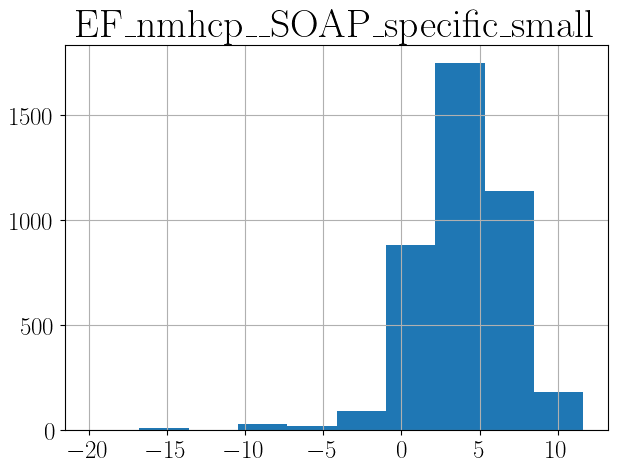

In [135]:
Prediction_Values['SOAP_specific_small', 'P'].hist('EF_nmhcp__SOAP_specific_small')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

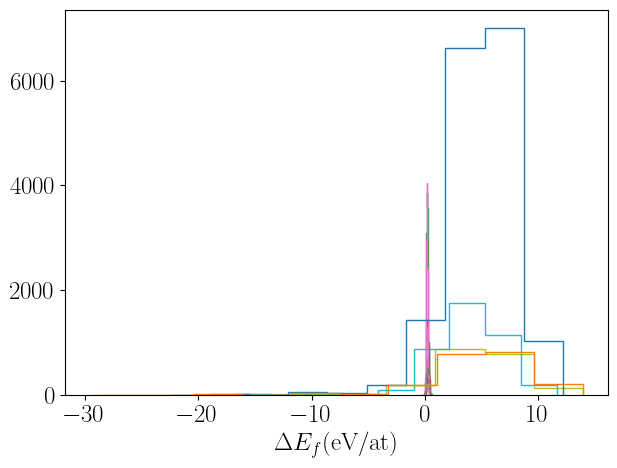

In [136]:
fig, axes = plt.subplots()
for key, serie in Prediction_Values.items():
    axes.hist(Prediction_Values[key][f'{target_case}__{key[0]}'], histtype='step')
axes.set_xlabel(r'$\Delta E_f $(eV/at)')

In [137]:
select_model = '0.7dprojections_0.5os'

In [138]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [139]:
difference =TRAIN_RBS.index.difference(coincidence)

In [140]:
TRAIN_RBS.loc[difference]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076915,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,52,1,53,0.981132,0.018868,NM,R,0.228834,0.159020,0.081452


In [141]:
len( featurenames)

3

In [142]:
featurenames

{'0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP_specific_small'}

In [143]:
BS_predict.keys()

dict_keys(['R', 'P', 'delta', 'M'])

Text(0.5, 0.01, '$x_{Fe}$')

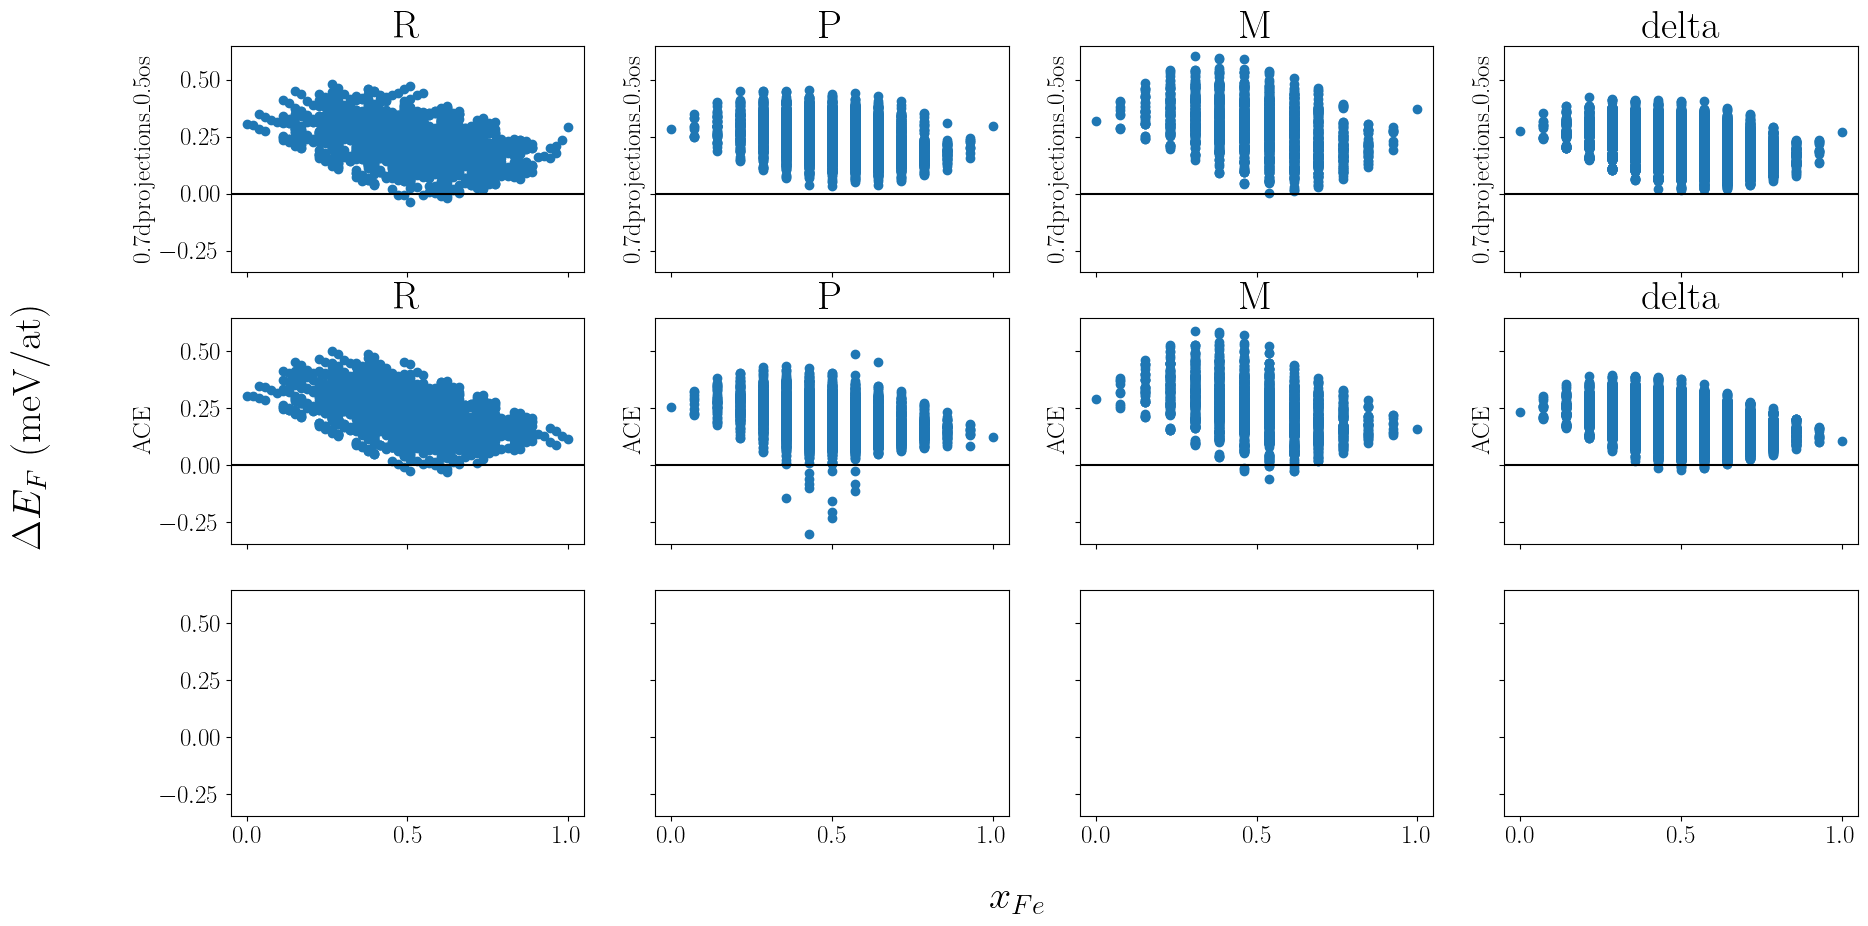

In [144]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
phase_pos = {'R': 0, 'P': 1, 'M': 2, 'delta': 3}
fig, axes = plt.subplots(
    len(featurenames), len(BS_predict),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]*2),
    sharey=True, sharex=True)
for (featurename, phase), prediction  in Prediction_Values.items():
    if 'SOAP' in featurename :
        continue
    I = featurename_pos[featurename]
    J = phase_pos[phase]
    intersection = BS_predict[phase]['Fe_pv'].index.intersection(prediction[f'{target_case}__{featurename}'].index)
    axes[I, J].scatter(
        BS_predict[phase]['Fe_pv'][intersection],
        prediction[f'{target_case}__{featurename}'][intersection],
    )
    axes[I,J].set_title(phase)
    axes[I,J].set_ylabel(featurename)
    axes[I,J].axhline(c='k')
fig.supylabel(r'$\Delta E_F$ (meV/at)')
fig.supxlabel(r'$x_{Fe}$')

In [110]:
DS.Features['SOAP_specific_small'].astype(float)

,Structure,Mag,SOAP_0_0,SOAP_0_CN12,SOAP_0_CN13,SOAP_0_CN14,SOAP_0_CN15,SOAP_0_CN16,SOAP_1_0,SOAP_1_CN12,...,SOAP_463_0,SOAP_463_CN12,SOAP_464_0,SOAP_465_0,SOAP_465_CN12,SOAP_466_0,SOAP_466_CN12,SOAP_467_0,SOAP_467_CN12,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3.0,1.0,0.003548,1.100630e-09,0.0,0.000000e+00,0.000000e+00,3.548093e-03,-0.000043,-7.725914e-09,...,-1.844499e-05,-1.412976e-05,1.265937e-05,2.933013e-05,2.450387e-05,-2.303407e-05,-2.019933e-05,1.965437e-05,1.798767e-05,0.371228
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4.0,0.0,0.006040,6.040270e-03,0.0,4.913540e-09,1.180171e-12,7.617016e-10,-0.000106,-1.062721e-04,...,-8.742242e-05,-4.502592e-05,6.219756e-05,1.425454e-04,8.597527e-05,-1.136796e-04,-7.479085e-05,9.695101e-05,6.886056e-05,0.203618
Fe_pv2Mo_sv11.mu-BBABB.FM,9.0,1.0,0.003276,2.366251e-11,0.0,4.881885e-09,3.275673e-03,0.000000e+00,-0.000039,1.439897e-10,...,-5.338776e-05,-2.520314e-05,4.071696e-05,8.670644e-05,4.430899e-05,-6.848669e-05,-3.686134e-05,5.528368e-05,3.158428e-05,0.857866
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10.0,0.0,0.005681,5.681428e-03,0.0,8.620213e-09,8.888411e-11,0.000000e+00,-0.000078,-7.821068e-05,...,-6.525249e-05,-2.705283e-05,4.515799e-05,9.279606e-05,4.373648e-05,-6.697798e-05,-3.409902e-05,4.983050e-05,2.715063e-05,0.013111
Fe_pv2Mo_sv11.mu-BBBBA.NM,9.0,0.0,0.003277,1.919843e-09,0.0,3.276565e-03,4.881885e-09,4.498950e-11,-0.000042,-6.384661e-09,...,-4.146490e-05,-8.853607e-06,2.902254e-05,6.395097e-05,1.509430e-05,-4.896684e-05,-1.259258e-05,3.969619e-05,1.243762e-05,0.026083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv29.chi.FM,6.0,1.0,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,-6.574674e-05,-2.992501e-05,4.515101e-05,1.058452e-04,6.495349e-05,-8.471435e-05,-6.063017e-05,7.410429e-05,5.918545e-05,0.853339
Fe_pv4Mo_sv2.C15-A2B.FM,2.0,1.0,0.014292,7.145922e-03,0.0,0.000000e+00,0.000000e+00,7.145918e-03,-0.000414,-2.072439e-04,...,-2.428441e-24,-1.849522e-24,1.824010e-24,3.930332e-24,2.953622e-24,-3.057728e-24,-2.278735e-24,2.425551e-24,1.791894e-24,0.781714
Fe_pv8Mo_sv16.C36-BAABB.NM,3.0,0.0,0.007095,3.547721e-03,0.0,0.000000e+00,0.000000e+00,3.547430e-03,-0.000079,-3.998140e-05,...,-2.969502e-05,-1.494679e-05,1.865746e-05,3.700904e-05,1.974361e-05,-2.448737e-05,-1.390218e-05,1.720179e-05,1.070561e-05,0.336543
Mo_sv8.A15.NM,0.0,0.0,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,-3.567561e-07,-1.189187e-07,3.926227e-07,2.737919e-06,9.126397e-07,-3.013177e-06,-1.004392e-06,3.316109e-06,1.105370e-06,0.377647


In [125]:
X = DS.Features['SOAP_specific_small']#.query('Mag == 0')
Y = DS.target#[X.index]
voting_regressor[('Kernel Ridge', 'SOAP_specific_small')].fit(X.astype(float), Y)

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7f3e79d123e0>,
                                                                  kw_args={'learning_curve':                  train1     test1   
SOAP_208_CN12  0.071192  0.071846  \
SOAP_11_CN12   0.060597  0.065868   
SOAP_240_CN16  0.040255  0.079745   
SOAP_212_0     0.033354  0.060270   
Mag            0.021429  0.072221   
...                 ...       ...   
SOAP_73_CN14   0.000097  0.042627   
SOAP_11...
SOAP_143_0     {'regressor__alpha': 0.1, 'regressor__coef0': ...  0.013537   

                  train  
SOAP_208_CN12  0.071480  
SOAP_209_CN16  0.061316  
SOAP_82_CN12   0.048015  
SOAP_202_CN15  0.043052  
SOAP_211_0     0.040534  
...                 ...  
SOAP_68_0      0.009656  
SOAP_84_CN12   0.009665  
SOAP_183_0     0.009681  
SOAP_138_0     0.009699  
SOAP_143_0     0.009719  

[251 rows x 5 columns],
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=0.1, coef0=5,
                                                          kernel='polynomial'))]))])

In [126]:
Learning_Predictions = voting_regressor[('Kernel Ridge', 'SOAP_specific_small')].predict(DS.Features['SOAP_specific_small'].astype(float))#()#DS.Features

In [127]:
Learning_Predictions = pd.Series(Learning_Predictions, index = DS.Features['SOAP_specific_small'].index, name = target_case)

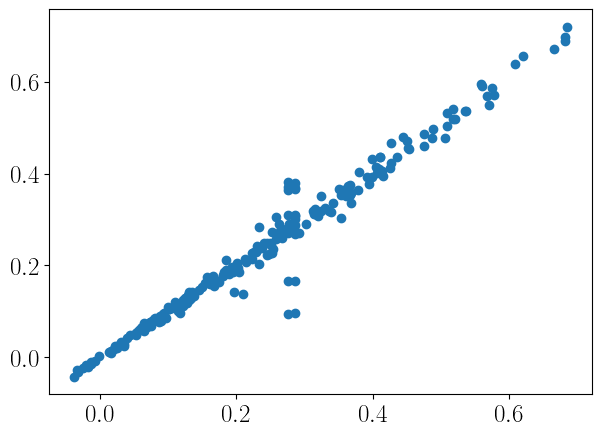

In [128]:
plt.scatter(Learning_Predictions, DS.target)

In [ ]:
BS_predict['R'].keys()

In [ ]:
target_case

In [ ]:
Prediction_Values.keys()

In [ ]:
Prediction_Values[('SOAP_specific_small', 'R')]

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
from scipy.stats import pearsonr, linregress

In [ ]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP' }
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*len(featurename_pos), plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x))
    ax.scatter(x, y) 
    ax.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    ax.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    ax.set_xlabel(featurename_label[featuregroup])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig('Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT.pdf')

In [ ]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

In [ ]:
Prediction_Values.keys()

In [ ]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, axes  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Prediction_Values[(bopmodel, phase)].index.intersection(Prediction_Values[(acemodel, phase)].index)
    x = Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    axes.scatter(x,y,edgecolor='k')
    axes.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    axes.set_title(phase_label[phase])
    axes.axhline(c='k')
    axes.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig('Fe-Mo/graphs/Fe-Mo-PredictionDifferences.pdf')

# Predicted convex hulls 

In [ ]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls

In [ ]:
from scipy.spatial import ConvexHull

In [ ]:
from matplotlib.lines import Line2D

In [ ]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [ ]:
BS_predict.keys()#['R'].filter(regex=target_case)

In [ ]:
phasesloc= {'R':0, 'M': 1,'P':2 ,'delta':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex='EF_nmhcp').columns)}

In [ ]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

In [ ]:
phase_labels = {'delta': r'$\delta$', 'R': '$R$', 'M': '$M$', 'P': '$P$'}

In [ ]:
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}

In [ ]:
x = experimental_range['R']

In [ ]:
BS_predict[phase].filter(regex='EF_')#columns#['Fe_pv', target_name, 'nelem']

In [ ]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}

for target_name, J in targetsloc.items():
    CHULLS[target_name] = {}
    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])
        chull = P.get_convex_hulls(
            {phase: plottable}, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0, -10)
        )
        CHULLS[target_name].update(chull)

        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')

print(f'Generated convex hulls for {len(targetsloc)} targets and {len(phasesloc)} phases.')

In [ ]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

## save chulls to csv

In [ ]:
for (phase, pred__model), chulldata in inchull.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    chull_data_loc = os.path.join(phase_chull_location, f'{ pred__model }.csv')
    chulldata.to_csv(chull_data_loc)

## save uncertainties to csv

In [ ]:
for (pred__model, phase), predictionvotes in Prediction_Values.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    votes_data_loc = os.path.join(phase_chull_location, f'{ pred__model }:votes.csv')
    predictionvotes.to_csv(votes_data_loc)

# Recover samples in convex hull for validation 

In [ ]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [ ]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [ ]:
inchull[('M', 'EF_nmhcp__ACE')]

## Plot predicted CHULL

In [ ]:
figsize = plt.rcParams['figure.figsize']
fig, axes = plt.subplots(
    len(targetsloc), len(phasesloc),
    sharey=True, sharex=True,
    figsize=(figsize[0] * 2.5, figsize[1] * 2),
)

for target_name, J in targetsloc.items():
    featurename = target_name.replace(target_case + '__', '')
    axes[J, 0].set_ylabel(feature_labels[featurename], fontsize=22)

    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if phase == 'R':
            axes[J, I].fill_between(experimental_range[phase], -0.1, 0.7, alpha=0.5)

        axes[J, I].scatter(
            plottable['Fe_pv'].values, plottable[target_name].values,
            c='brown', s=10, lw=0.1, edgecolor='w'
        )
        axes[0, I].set_title(phase_labels[phase], fontsize=22)

        l = axes[J, I].plot(
            inchull[(phase, target_name)]['Fe_pv'].values,
            inchull[(phase, target_name)][target_name].values,
            '-', color='brown', label='chull', linewidth=2
        )

        axes[J, I].axhline(c='k')
        axes[J, I].set_ylim([-0.06, 0.7])
        axes[J, I].set_xlim([0, 1])

fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supylabel(r'$\Delta E_F$ (eV/atom)', x=0.04, fontsize=26)
fig.supxlabel('$x_{Fe}$', fontsize=26, y=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.pdf')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.png', dpi=300)

## R chull with uncertainties

In [ ]:
featurename_pos = {'ACE':1}#{'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0,} # 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols*1.2,plt.rcParams['figure.figsize'][1]*nrows*1.2),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes.scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes.plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes.fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes.errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes.set_title(phase_label[phase], fontsize=22)
#    axes.set_ylabel(featurename_label[featuregroup], fontsize=22)
axes.set_xlabel('$x_{Fe}$')#, fontsize=24)
axes.set_ylabel(rf'$\Delta E_F$ (meV / atom)', fontsize=22)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')

## Predicted CHULLs with uncertainties

In [ ]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0, 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols,plt.rcParams['figure.figsize'][1]*nrows),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes[I,J].scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes[I,J].plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes[I,J].fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes[I,J].errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes[I,J].scatter(
#            BS['Fe_pv'][training_samples],
#            BS[target_case][training_samples]*1000,
#            edgecolor='k',
#            label='DFT calculations',
#            s = 100
#            )
        axes[0, J].set_title(phase_label[phase], fontsize=22)
#    axes[0,I].legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    axes[I,0].set_ylabel(featurename_label[featuregroup], fontsize=22)
fig.supxlabel('$x_{Fe}$', fontsize=24, y=0.04)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supylabel(r'$\Delta E_F$ (meV / atom)', fontsize=22, x=0.075)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [ ]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [ ]:
from scipy.spatial import Delaunay

In [ ]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [ ]:
import pdb

In [ ]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [ ]:
targetname=f'{target_case}__ACE'
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

In [ ]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [ ]:
distances_to_chull = pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)

In [ ]:
selection = xy.index.str.contains('NM')

In [ ]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

In [ ]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = axes)
ax2.set_axis_off()
axes.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
axes.set_xlabel ('distance to convex hull')
axes.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

In [ ]:
fig, axes = plt.subplots()
mapble = axes.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
axes.set_xlabel(r'$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_f$ (meV/atom)')
axes.set_title(ModelName+' / '+targetname)

In [ ]:
Phases = {'R':'R', 'delta': r'$\delta$', 'P': 'P', 'M':'M'}

In [ ]:
fig, axes = plt.subplots(1, len(Phases), sharey=True, figsize=(plt.rcParams['figure.figsize'][0]*len(Phases), plt.rcParams['figure.figsize'][1]))
for (phase, title), axes  in zip(Phases.items(), axes):
    inchull_bop = inchull[(phase, 'EF_nmhcp__0.7dprojections_0.5os')].index
    inchull_ace = inchull[(phase, 'EF_nmhcp__ACE')].index
    sbop, pbop = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop])
    sace, pace = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace])
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop]
        , y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop], label = f'BOP, $R^2 = {sbop:.3f}$',
        ax=axes
    )
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], 
        y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace], label = f'ACE, $R^2 = {sace:.3f}$', ax = axes, 
    )
    axes.set_xlabel('')
    axes.set_title(title)
fig.supxlabel ('BOP', y=-0.1)
fig.supylabel ('ACE', x=0.01)
plt.savefig(f'{dataset}/graphs/samples_in_convex_hull.pdf')

# Recover samples in convex hull for validation 

In [ ]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [ ]:
ValidationDataLocation

In [ ]:
pd.concat(inchull, axis =0).to_csv(os.path.join(ValidationDataLocation, 'inchull.csv'))

In [ ]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [ ]:
inchull.keys()

In [ ]:
inchull[('delta', 'EF_nmhcp__ACE')]


In [ ]:
inchullist

In [ ]:
target_name

In [ ]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, 'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [ ]:
inchull[('R','EF_nmhcp__0.7dprojections_0.5os' )].shape

In [ ]:
AtomsObjects[phase]['atoms'][inchullist.index]